
 Running Biological Evaluation 
SIMPLIFIED EVALUATION RULES:
- Single Source: Exactly 1 carbon source total (exact match required)
- Co-utilization: All other cases (accounts for multiauxie and B co-utilization)
  • With A sources: Exactly 1A + ≥1B (multiauxie for A)
  • Without A sources: ≥2B (B groups can co-utilize)
- Pure multiauxie (multiple A + zero B): Excluded

===== Data Filtering Summary =====
Total original cases: 110
Pure multiauxie cases excluded: 19
Cases analyzed: 91

--- Case Breakdown ---
Single Source: 10
Co-utilization: 81
Total analyzed: 91

===== Overall Accuracy =====
AMN overall accuracy:   34.07%
ecAMN overall accuracy: 48.35%
Δ Accuracy (ecAMN – AMN): 14.29%

===== Accuracy by Scenario =====

--- Single Source ---
Total cases:       10
AMN correct:       8/10 (80.00%)
ecAMN correct:     10/10 (100.00%)
Δ Accuracy:        +20.00%

--- Co-utilization ---
Total cases:       81
AMN correct:       23/81 (28.40%)
ecAMN correct:     34/81 (41.98%)
Δ Accuracy:        

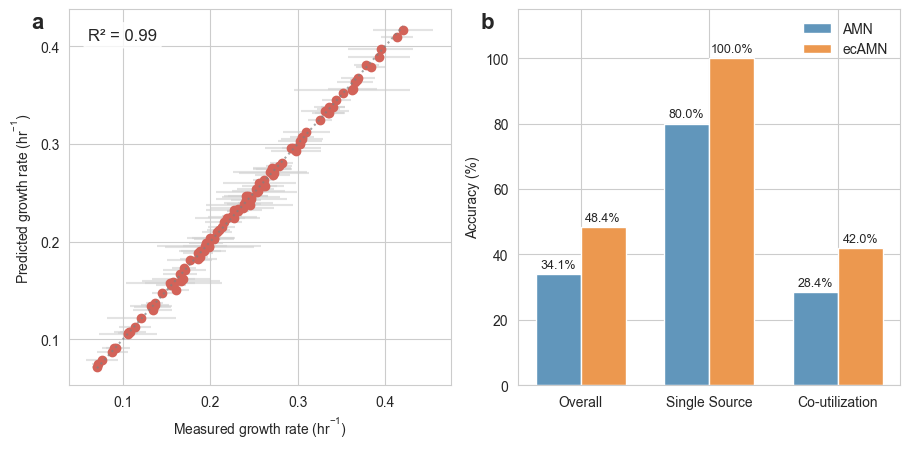


===== Full Prediction Table (first 20 rows) =====
    Index              Phenotype  \
0       0          Single Source   
1       1          Single Source   
2       2          Single Source   
3       3          Single Source   
4       4          Single Source   
5       5          Single Source   
6       6          Single Source   
7       7          Single Source   
8       8          Single Source   
9       9          Single Source   
10     10  Multiauxie (excluded)   
11     11         Co-utilization   
12     12         Co-utilization   
13     13  Multiauxie (excluded)   
14     14  Multiauxie (excluded)   
15     15         Co-utilization   
16     16  Multiauxie (excluded)   
17     17  Multiauxie (excluded)   
18     18         Co-utilization   
19     19         Co-utilization   

                                                Notes  Setup_A  Setup_B  \
0                    Exact match required: 1.0A, 0.0B        1        0   
1                    Exact match required:

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import r2_score

subplot_label_x_coordinate = -0.1
subplot_label_y_coordinate = 0.95

# ====================================================================
# 1. Data Processing
# ====================================================================

def process_dataframe(csv_input):
    group_a_cols = ['EX_fru_e_i', 'EX_gal_e_i', 
                    'EX_malt_e_i', 'EX_melib_e_i', 'EX_rib__D_e_i', 'EX_tre_e_i']
    group_b_cols = ['EX_ac_e_i', 'EX_pyr_e_i', 'EX_succ_e_i', 'EX_lac__D_e_i']
    
    try:
        df = pd.read_csv(csv_input)
        for col in group_a_cols + group_b_cols:
            if col not in df.columns:
                df[col] = 0
        df['active_A'] = (df[group_a_cols] > 0).sum(axis=1)
        df['active_B'] = (df[group_b_cols] > 0).sum(axis=1)
        return df
    except Exception as e:
        print(f"Error processing data: {e}")
        return None

# ====================================================================
# 2. Biological Evaluation - SIMPLIFIED RULES
# ====================================================================

def evaluate_biological_rules(setup_row, amn_row, ecamn_row):
    setup_a, setup_b = setup_row['active_A'], setup_row['active_B']
    amn_a,   amn_b   = amn_row['active_A'], amn_row['active_B']
    ecamn_a, ecamn_b = ecamn_row['active_A'], ecamn_row['active_B']

    amn_correct = False
    ecamn_correct = False

    # ---------------------------
    # Pure multiauxie (exclude - FBA cannot capture)
    # Multiple A (>=2) and zero B
    # ---------------------------
    if setup_a >= 2 and setup_b == 0:
        return {
            'Phenotype': 'Multiauxie (excluded)',
            'AMN_Correct': False,
            'ecAMN_Correct': False,
            'Notes': 'FBA cannot capture multiauxie dynamics'
        }

    # ---------------------------
    # Single source (total = 1)
    # ---------------------------
    if setup_a + setup_b == 1:
        # For single source, require exact match
        if (amn_a == setup_a and amn_b == setup_b):
            amn_correct = True
        if (ecamn_a == setup_a and ecamn_b == setup_b):
            ecamn_correct = True

        phenotype = "Single Source"
        notes = f"Exact match required: {setup_a}A, {setup_b}B"

    # ---------------------------
    # Co-utilization cases (ALL cases with at least one B)
    # ---------------------------
    else:
        # SIMPLIFIED RULE: Co-utilization = exactly 1A + ≥1B (due to multiauxie for A)
        # OR 0A + ≥2B (B groups can co-utilize with each other)
        if setup_a >= 1:
            # Cases with A: require exactly 1A (multiauxie) + ≥1B
            if (amn_a == 1 and amn_b >= 1):
                amn_correct = True
            if (ecamn_a == 1 and ecamn_b >= 1):
                ecamn_correct = True
        else:
            # Cases with 0A + multiple B: require ≥2B (B groups co-utilizing)
            if (amn_a == 0 and amn_b >= 2):
                amn_correct = True
            if (ecamn_a == 0 and ecamn_b >= 2):
                ecamn_correct = True

        phenotype = "Co-utilization"
        amn_status = "✓" if amn_correct else f"✗ ({amn_a}A, {amn_b}B)"
        ecamn_status = "✓" if ecamn_correct else f"✗ ({ecamn_a}A, {ecamn_b}B)"
        notes = f"Setup: {setup_a}A, {setup_b}B → Expected: {1 if setup_a >= 1 else 0}A + ≥{1 if setup_a >= 1 else 2}B | AMN: {amn_status} | ecAMN: {ecamn_status}"

    return {
        'Phenotype': phenotype,
        'AMN_Correct': amn_correct,
        'ecAMN_Correct': ecamn_correct,
        'Notes': notes
    }

def run_biological_evaluation(df_setup, df_amn, df_ecamn):
    results = []
    for i in range(len(df_setup)):
        results.append(
            evaluate_biological_rules(df_setup.loc[i], df_amn.loc[i], df_ecamn.loc[i])
        )
    return pd.DataFrame(results)

# ====================================================================
# 3. Pattern Analysis
# ====================================================================

def analyze_biological_patterns(results_df):
    # Filter out pure multiauxie cases
    filtered_df = results_df[results_df['Phenotype'] != 'Multiauxie (excluded)']
    
    patterns = {
        'Single Source': {'amn': 0, 'ecamn': 0, 'total': 0},
        'Co-utilization': {'amn': 0, 'ecamn': 0, 'total': 0},
    }

    for _, row in filtered_df.iterrows():
        ph = row['Phenotype']
        patterns[ph]['total'] += 1
        if row['AMN_Correct']: patterns[ph]['amn'] += 1
        if row['ecAMN_Correct']: patterns[ph]['ecamn'] += 1

    return patterns, filtered_df

# ====================================================================
# 4. McNemar Test
# ====================================================================

def perform_mcnemar_test(results_df):
    # Filter out multiauxie cases
    filtered_df = results_df[results_df['Phenotype'] != 'Multiauxie (excluded)']
    
    amn = filtered_df['AMN_Correct'].astype(int)
    ecamn = filtered_df['ecAMN_Correct'].astype(int)

    a = ((amn == 1) & (ecamn == 1)).sum()
    b = ((amn == 1) & (ecamn == 0)).sum()
    c = ((amn == 0) & (ecamn == 1)).sum()
    d = ((amn == 0) & (ecamn == 0)).sum()

    table = [[a, b],
             [c, d]]

    result = mcnemar(table, exact=True)
    return result.pvalue, table

# ====================================================================
# 5. Combined Visualization - SUBPLOTS a and b
# ====================================================================

def create_combined_figure(patterns, overall_amn, overall_ecamn):
    plt.close('all')
    
    # Set up the style
    sns.set_style("whitegrid")
    plt.rcParams["font.family"] = "Arial"
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.2, 4.6))
    
    # ===========================================
    # Subplot a: Growth Rate Comparison
    # ===========================================
    ref_xpal = "EXP110.csv"
    xpal_df = pd.read_csv(ref_xpal, header=0, index_col=0)
    ref_gr_avg = xpal_df["GR_AVG"]
    ref_gr_std = xpal_df["GR_STD"]

    cobra_train = "20250503125046_2000-0-5_seed14_fixedseed_alr_iML1515_ec6_UB_AMN_QP_RC_PRED.csv"

    identity = [min(ref_gr_avg), max(ref_gr_avg)]

    data = pd.read_csv(cobra_train, header=None, delimiter=",").astype(np.float32)
    data = data.T
    preds_avg = data.iloc[:,0].to_list()
    q2 = r2_score(ref_gr_avg.to_list(), preds_avg)
    
    ax1.plot(identity, identity, ':', color='gray', alpha=0.7)
    # Changed color to blue for measured growth rate
    ax1.scatter(ref_gr_avg, preds_avg, zorder=1, color="#D36359")  # Blue color
    ax1.errorbar(ref_gr_avg, preds_avg, xerr=ref_gr_std, ls="none", zorder=0, color="#D1D1D1", alpha=0.6)

    # Remove title and put R² inside the plot
    ax1.text(0.05, 0.95, f'R² = 0.99', transform=ax1.transAxes, 
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax1.set_xlabel("Measured growth rate (" + r'$\mathregular{hr^{-1}}$' + ")")
    ax1.set_ylabel("Predicted growth rate (" + r'$\mathregular{hr^{-1}}$' + ")")
    ax1.set_xticks([0.1, 0.2, 0.3, 0.4])
    ax1.set_xticklabels(['0.1', '0.2', '0.3', '0.4'])
    ax1.set_yticks([0.1, 0.2, 0.3, 0.4])
    ax1.set_yticklabels(['0.1', '0.2', '0.3', '0.4'])
    
    # Add subplot label a (lowercase)
    ax1.text(subplot_label_x_coordinate, subplot_label_y_coordinate, "a", transform=ax1.transAxes, fontsize=16, fontweight="bold")

    # ===========================================
    # Subplot b: Scenario Accuracy
    # ===========================================
    # Include overall accuracy in the plot
    scenarios = ["Overall", "Single Source", "Co-utilization"]
    
    # Calculate accuracies
    amn_acc = [overall_amn]
    ecamn_acc = [overall_ecamn]
    
    for sc in ["Single Source", "Co-utilization"]:
        tot = patterns[sc]['total']
        if tot > 0:
            amn_acc.append(patterns[sc]['amn'] / tot * 100)
            ecamn_acc.append(patterns[sc]['ecamn'] / tot * 100)
        else:
            amn_acc.append(0)
            ecamn_acc.append(0)

    x = np.arange(len(scenarios))
    width = 0.35
    colors = {"AMN": "#6196bb", "ecAMN": "#EC984F"}

    bars1 = ax2.bar(x - width/2, amn_acc, width, label="AMN", color=colors["AMN"])
    bars2 = ax2.bar(x + width/2, ecamn_acc, width, label="ecAMN", color=colors["ecAMN"])

    # Add accuracy labels on top of bars
    for i, (bar1, bar2, acc1, acc2) in enumerate(zip(bars1, bars2, amn_acc, ecamn_acc)):
        # AMN bars
        ax2.text(bar1.get_x() + bar1.get_width()/2., bar1.get_height() + 1,
                f'{acc1:.1f}%', ha='center', va='bottom', fontsize=9)
        # ecAMN bars
        ax2.text(bar2.get_x() + bar2.get_width()/2., bar2.get_height() + 1,
                f'{acc2:.1f}%', ha='center', va='bottom', fontsize=9)

    ax2.set_ylabel("Accuracy (%)")
    ax2.set_xticks(x)
    ax2.set_xticklabels(scenarios)
    ax2.set_ylim(0, 115)
    ax2.legend(frameon=False)
    
    # Add subplot label b (lowercase)
    ax2.text(subplot_label_x_coordinate, subplot_label_y_coordinate, "b", transform=ax2.transAxes, fontsize=16, fontweight="bold")

    plt.tight_layout()

    plt.savefig("combined_figure.png", dpi=1000)
    plt.savefig("combined_figure.svg")

    plt.show()
    return fig

# ====================================================================
# 6. Full Table Generator
# ====================================================================

def generate_full_result_table(df_setup, df_amn, df_ecamn, results_df):
    rows = []
    for i in range(len(df_setup)):
        rows.append({
            "Index": i,
            "Phenotype": results_df.loc[i, "Phenotype"],
            "Notes": results_df.loc[i, "Notes"],

            "Setup_A": df_setup.loc[i, "active_A"],
            "Setup_B": df_setup.loc[i, "active_B"],

            "AMN_A": df_amn.loc[i, "active_A"],
            "AMN_B": df_amn.loc[i, "active_B"],
            "AMN_Correct": results_df.loc[i, "AMN_Correct"],

            "ecAMN_A": df_ecamn.loc[i, "active_A"],
            "ecAMN_B": df_ecamn.loc[i, "active_B"],
            "ecAMN_Correct": results_df.loc[i, "ecAMN_Correct"],
        })
    return pd.DataFrame(rows)

# ====================================================================
# 7. Main Pipeline - SIMPLIFIED RULES
# ====================================================================

def run_analysis(df_setup, df_amn, df_ecamn):
    print("\n==============================================")
    print(" Running Biological Evaluation ")
    print("==============================================")
    print("SIMPLIFIED EVALUATION RULES:")
    print("- Single Source: Exactly 1 carbon source total (exact match required)")
    print("- Co-utilization: All other cases (accounts for multiauxie and B co-utilization)")
    print("  • With A sources: Exactly 1A + ≥1B (multiauxie for A)")
    print("  • Without A sources: ≥2B (B groups can co-utilize)")
    print("- Pure multiauxie (multiple A + zero B): Excluded")
    print("==============================================")

    results_df = run_biological_evaluation(df_setup, df_amn, df_ecamn)
    patterns, filtered_results_df = analyze_biological_patterns(results_df)

    # Analysis summary
    multiauxie_count = (results_df['Phenotype'] == 'Multiauxie (excluded)').sum()
    total_original_cases = len(results_df)
    total_analyzed_cases = len(filtered_results_df)

    print(f"\n===== Data Filtering Summary =====")
    print(f"Total original cases: {total_original_cases}")
    print(f"Pure multiauxie cases excluded: {multiauxie_count}")
    print(f"Cases analyzed: {total_analyzed_cases}")

    # Case breakdown
    co_utilization_cases = patterns["Co-utilization"]["total"]
    single_source_cases = patterns["Single Source"]["total"]
    
    print(f"\n--- Case Breakdown ---")
    print(f"Single Source: {single_source_cases}")
    print(f"Co-utilization: {co_utilization_cases}")
    print(f"Total analyzed: {single_source_cases + co_utilization_cases}")

    # Global Accuracy
    amn_global = filtered_results_df['AMN_Correct'].mean() * 100
    ecamn_global = filtered_results_df['ecAMN_Correct'].mean() * 100

    print("\n===== Overall Accuracy =====")
    print(f"AMN overall accuracy:   {amn_global:.2f}%")
    print(f"ecAMN overall accuracy: {ecamn_global:.2f}%")
    print(f"Δ Accuracy (ecAMN – AMN): {ecamn_global - amn_global:.2f}%")

    # Scenario Accuracy
    print("\n===== Accuracy by Scenario =====")
    for scenario in ["Single Source", "Co-utilization"]:
        total = patterns[scenario]["total"]
        amn_correct = patterns[scenario]["amn"]
        ecamn_correct = patterns[scenario]["ecamn"]

        if total > 0:
            amn_acc = amn_correct / total * 100
            ecamn_acc = ecamn_correct / total * 100
            delta = ecamn_acc - amn_acc
        else:
            amn_acc = ecamn_acc = delta = 0

        print(f"\n--- {scenario} ---")
        print(f"Total cases:       {total}")
        print(f"AMN correct:       {amn_correct}/{total} ({amn_acc:.2f}%)")
        print(f"ecAMN correct:     {ecamn_correct}/{total} ({ecamn_acc:.2f}%)")
        print(f"Δ Accuracy:        {delta:+.2f}%")

    # McNemar Test
    p_value, table = perform_mcnemar_test(results_df)
    a, b = table[0]
    c, d = table[1]

    print("\n===== McNemar Test =====")
    print("                  ecAMN Correct | ecAMN Wrong")
    print(f"AMN Correct          {a:4d}       |    {b:4d}")
    print(f"AMN Wrong            {c:4d}       |    {d:4d}")
    print(f"\nMcNemar p-value: {p_value}")

    # Biological Insights
    print("\n===== Key Biological Insights =====")
    print("• SIMPLIFIED evaluation: Only two categories")
    print("• Single Source: Exactly 1 carbon source")
    print("• Co-utilization: All other valid cases")
    print("• Accounts for multiauxie (A sources) and B co-utilization")
    
    if patterns["Co-utilization"]["total"] > 0:
        co_amn_acc = patterns["Co-utilization"]["amn"] / patterns["Co-utilization"]["total"] * 100
        co_ecamn_acc = patterns["Co-utilization"]["ecamn"] / patterns["Co-utilization"]["total"] * 100
        
        print(f"\n--- Co-utilization Performance ---")
        print(f"AMN accuracy:    {co_amn_acc:.1f}%")
        print(f"ecAMN accuracy:  {co_ecamn_acc:.1f}%")
        
        if co_ecamn_acc > co_amn_acc:
            improvement = co_ecamn_acc - co_amn_acc
            print(f"ecAMN improvement: +{improvement:.1f}%")
            print("→ ecAMN better captures biological utilization patterns!")

    print("\n==============================================")
    print(" Generating Combined Figure (a and b)...")
    print("==============================================\n")

    # Create combined figure with subplots a and b
    fig = create_combined_figure(patterns, amn_global, ecamn_global)

    # Create full table
    full_table = generate_full_result_table(df_setup, df_amn, df_ecamn, results_df)

    return {
        "results_df": results_df,
        "filtered_results_df": filtered_results_df,
        "patterns": patterns,
        "mcnemar_p": p_value,
        "mcnemar_table": table,
        "figure": fig,
        "full_table": full_table,
        "multiauxie_count": multiauxie_count,
        "overall_amn": amn_global,
        "overall_ecamn": ecamn_global
    }

# ====================================================================
# 8. Execute
# ====================================================================

if __name__ == "__main__":
    setup_file = 'iML1515_EXP.csv'
    amn_file = 'iML1515_UB_AMN_QP_RC_AMN_solution_for_Cobra_train.csv'
    ecamn_file = '20250503232341_1000-0-5_seed14_fixedseed_alr_iML1515_ec6_UB_AMN_QP_RC_solution_for_Cobra.csv'

    df_setup = process_dataframe(setup_file)
    df_amn = process_dataframe(amn_file)
    df_ecamn = process_dataframe(ecamn_file)

    if all(df is not None for df in [df_setup, df_amn, df_ecamn]):
        results = run_analysis(df_setup, df_amn, df_ecamn)
        
        results_df = results["results_df"]
        filtered_results_df = results["filtered_results_df"]
        full_table = results["full_table"]

        print("\n===== Full Prediction Table (first 20 rows) =====")
        print(full_table.head(20))

        full_table.to_csv("full_prediction_table.csv", index=False)

        # Final validation
        phenotypes = full_table['Phenotype'].value_counts()
        print(f"\n=== Final Summary ===")
        for phenotype, count in phenotypes.items():
            print(f"{phenotype}: {count} cases")

    else:
        print("Error loading files.")